In [1]:
import torch
from d2l import torch as d2l
import torchvision
import os
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
import matplotlib.pyplot as plt
import os
import warnings
from torch.utils.data import DataLoader
import torchvision.utils as vutils


d2l.DATA_HUB['pokemon'] = (d2l.DATA_URL + 'pokemon.zip', 'c065c0e2593b8b161a2d7873e42418bf6a21106c')
data_dir = d2l.download_extract('pokemon')
transform = transforms.Compose([
    transforms.Resize((64, 64)), 
    transforms.ToTensor(), 
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

pokemon = torchvision.datasets.ImageFolder(data_dir, transform=transform)
batch_size = 128
dataloader = DataLoader(pokemon, batch_size=batch_size, shuffle=True, num_workers=4)
print(f'Number of images: {len(pokemon)}')


Number of images: 40597


In [2]:
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)


In [5]:
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

nz = 100 #noise vector size
ngf = 64 #Generatore feature maps
ndf = 64 #Discriminator feature maps
lr = 0.0002
beta1 = 0.5 #beta1 for Adam


netG = Generator(nz, ngf, 3).to(device)
netD = Discriminator(3, ndf).to(device)
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))


def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)
netD.apply(weights_init)

os.makedirs('dcgan_images', exist_ok=True)

fixed_noise = torch.randn(64, nz, 1, 1, device=device)

img_list = []
G_losses = []
D_losses = []

num_epochs = 30

print("Starting Training Loop...")

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(dataloader):

        netD.zero_grad()

        real_images = real_images.to(device)
        b_size = real_images.size(0)
        label = torch.full((b_size,), 1., dtype=torch.float, device=device)
        
        output = netD(real_images).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise)
        label.fill_(0.)
        
        output = netD(fake_images.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()
        netG.zero_grad()
        label.fill_(1.)
        output = netD(fake_images).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        
        optimizerG.step()
        G_losses.append(errG.item())
        D_losses.append(errD.item())
        
        if (i % 100 == 0) or (epoch == num_epochs-1 and i == len(dataloader)-1):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

    print(f'[{epoch+1}/{num_epochs}] Loss_D: {errD.item():.4f} | Loss_G: {errG.item():.4f} | Realness D(x): {D_x:.4f} | Fakeness D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}')
    
    # sample images every 5 epochs is saved
    if (epoch+1) % 5 == 0 or epoch == 0:
        vutils.save_image(fake, f'dcgan_images/fake_images_epoch_{epoch+1}.png', normalize=True)


Using device: cuda
Starting Training Loop...
[1/30] Loss_D: 0.3237 | Loss_G: 4.8959 | Realness D(x): 0.9297 | Fakeness D(G(z)): 0.2075/0.0093
[2/30] Loss_D: 0.7611 | Loss_G: 2.1421 | Realness D(x): 0.5317 | Fakeness D(G(z)): 0.0100/0.1773
[3/30] Loss_D: 0.4091 | Loss_G: 4.1760 | Realness D(x): 0.8922 | Fakeness D(G(z)): 0.2259/0.0197
[4/30] Loss_D: 0.3484 | Loss_G: 3.3924 | Realness D(x): 0.8331 | Fakeness D(G(z)): 0.1268/0.0408
[5/30] Loss_D: 0.2310 | Loss_G: 2.1746 | Realness D(x): 0.8332 | Fakeness D(G(z)): 0.0340/0.1431
[6/30] Loss_D: 0.2286 | Loss_G: 3.5072 | Realness D(x): 0.8624 | Fakeness D(G(z)): 0.0683/0.0399
[7/30] Loss_D: 0.3978 | Loss_G: 2.2691 | Realness D(x): 0.7524 | Fakeness D(G(z)): 0.0807/0.1339
[8/30] Loss_D: 0.2667 | Loss_G: 4.4998 | Realness D(x): 0.8982 | Fakeness D(G(z)): 0.1058/0.0179
[9/30] Loss_D: 0.2423 | Loss_G: 4.8268 | Realness D(x): 0.9234 | Fakeness D(G(z)): 0.1386/0.0099
[10/30] Loss_D: 0.2077 | Loss_G: 3.3203 | Realness D(x): 0.8516 | Fakeness D(G(z))

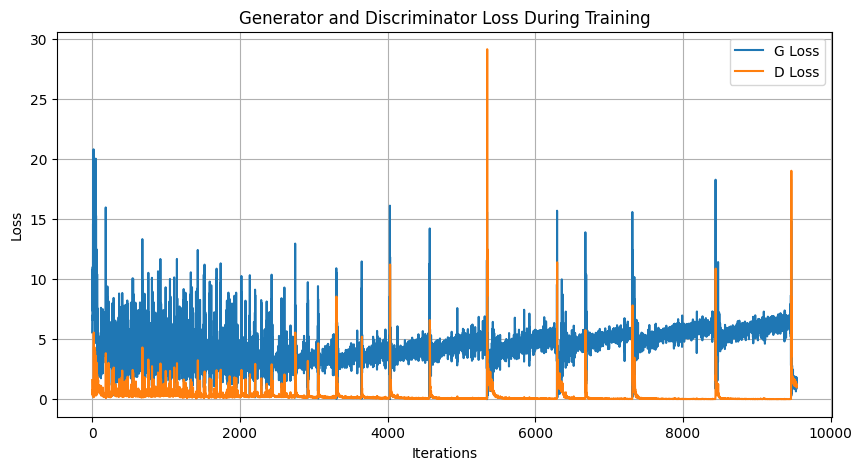

In [6]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


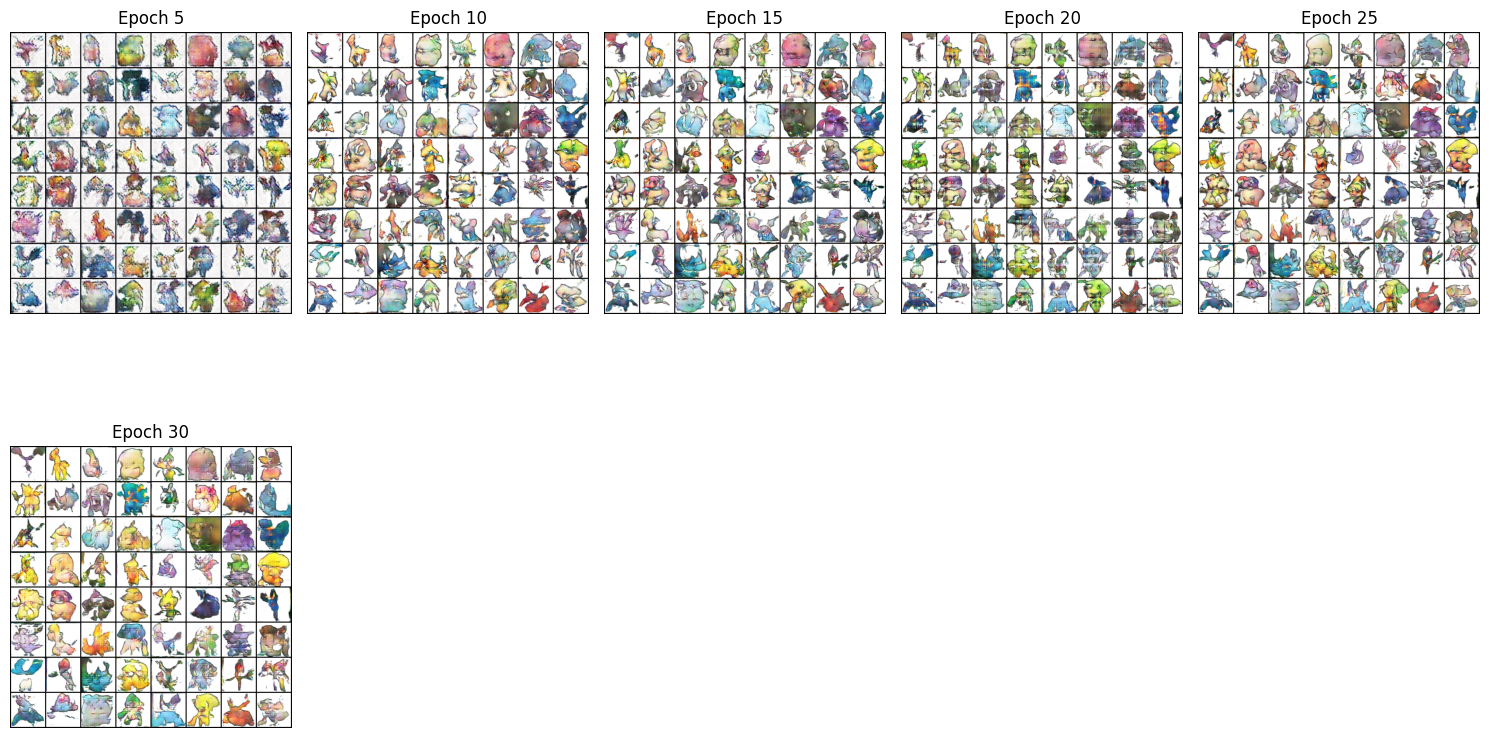

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import os

epochs = list(range(5, 31, 5))
plt.figure(figsize=(15, 9))
for idx, epoch in enumerate(epochs):
    img_path = f'dcgan_images/fake_images_epoch_{epoch}.png'
    img = Image.open(img_path)
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Epoch {epoch}")
plt.tight_layout()
plt.show()
